# Used car 🚘 price 💵 prediction

## Importing

In [106]:
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the data
Source: [Kaggle](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)

In [107]:
# !mkdir ../data
# !wget -q https://www.kaggle.com/api/v1/datasets/download/austinreese/craigslist-carstrucks-data -O ../data/cars.zip
# !unzip -q ../data/cars.zip -d ../data/
# !ls ../data/

In [108]:
df = pd.read_csv ("../data/vehicles.csv")
df.shape

(426880, 26)

## Understand dataset 🧐

In [109]:
for col in df.columns:
    print (f"Col name: {col}")
    print (f"No.of unique values: {len (df [col].unique ())}")
    print (f"First 4 unique values: {df [col].unique ().tolist () [: 4]}")
    print ('-' * 50)
    print ()

Col name: id
No.of unique values: 426880
First 4 unique values: [7222695916, 7218891961, 7221797935, 7222270760]
--------------------------------------------------

Col name: url
No.of unique values: 426880
First 4 unique values: ['https://prescott.craigslist.org/cto/d/prescott-2010-ford-ranger/7222695916.html', 'https://fayar.craigslist.org/ctd/d/bentonville-2017-hyundai-elantra-se/7218891961.html', 'https://keys.craigslist.org/cto/d/summerland-key-2005-excursion/7221797935.html', 'https://worcester.craigslist.org/cto/d/west-brookfield-2002-honda-odyssey-ex/7222270760.html']
--------------------------------------------------

Col name: region
No.of unique values: 404
First 4 unique values: ['prescott', 'fayetteville', 'florida keys', 'worcester / central MA']
--------------------------------------------------

Col name: region_url
No.of unique values: 413
First 4 unique values: ['https://prescott.craigslist.org', 'https://fayar.craigslist.org', 'https://keys.craigslist.org', 'https://

In [110]:
df.head ()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [111]:
df ['model'].sample (10)

,model
27978,rogue
211924,express passenger
204977,impala
222321,beetle coupe
49637,impreza premium
379361,2500
99147,640i
91798,f-550
101333,f-150
135349,lancer evolution


# READY? 🥸

### Drop useless cols like:- (URLs, ID, ...) 🤷‍♂️

In [112]:
useless_cols = ['id', 'url', 'region_url', 'VIN', 'image_url', 'description', 'county', 'lat', 'long']
# I droped lat and long -> We have state and it is enough

In [113]:
df.drop (columns= useless_cols, inplace= True)
df.columns


Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'size', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

In [114]:
# We wil use them later

num_of_rows = df.shape [0]
SIZE = len (df)
to_do = []

print (f"Shape: {df.shape}")
print (f"No.of rows: {num_of_rows}")
print (f"SIZE: {SIZE}")


def append_to_to_do (task):
    if task not in to_do:
        to_do.append (task)

Shape: (426880, 17)
No.of rows: 426880
SIZE: 426880


In [115]:
task = {
    "columns": useless_cols,
    "action": "drop useless columns"
}

append_to_to_do (task)

## duplicates 🚙🚙

In [116]:
df.duplicated ().sum ()

np.int64(39)

In [117]:
df.drop_duplicates (inplace= True)
df.duplicated ().sum ()

np.int64(0)

In [118]:
task = {
    "columns": df.columns.tolist(),
    "action": "drop duplicates"
}
append_to_to_do (task)

## missing values

In [119]:
na = df.isna ().sum ()
percentage = (na / len(df) * 100).round (2)

missing = pd.DataFrame({
    "missing": na,
    "percentage": percentage
})

missing = missing [missing["missing"] > 0]
missing = missing.sort_values("missing", ascending=False)

missing

,missing,percentage
size,306325,71.77
cylinders,177654,41.62
condition,174080,40.78
drive,130550,30.59
paint_color,130181,30.50
type,92847,21.75
manufacturer,17635,4.13
title_status,8221,1.93
model,5266,1.23
odometer,4389,1.03


In [120]:
df.drop ('size', axis= 1, inplace= True)
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

In [121]:
na = df.isna ().sum ()
percentage = (na / len(df) * 100).round (2)

missing = pd.DataFrame({
    "missing": na,
    "percentage": percentage
})

missing = missing [missing["missing"] > 0]
missing = missing.sort_values("missing", ascending=False)

missing

,missing,percentage
cylinders,177654,41.62
condition,174080,40.78
drive,130550,30.59
paint_color,130181,30.50
type,92847,21.75
manufacturer,17635,4.13
title_status,8221,1.93
model,5266,1.23
odometer,4389,1.03
fuel,3002,0.70


In [122]:
na_cat_cols = df.select_dtypes (include="object").columns [    df.select_dtypes (include="object").isna ().any ()
].tolist ()

na_num_cols = df.select_dtypes (include="number").columns [
    df.select_dtypes (include="number").isna().any()
].tolist()

print (na_cat_cols)
print (na_num_cols)

['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'posting_date']
['year', 'odometer']


### Numerical columns

In [123]:
df [na_num_cols].describe ()

,year,odometer
count,"425,647.00","422,452.00"
mean,"2,011.23","98,045.19"
std,9.45,"213,887.96"
min,"1,900.00",0.00
25%,"2,008.00","37,710.00"
50%,"2,013.00","85,548.00"
75%,"2,017.00","133,544.25"
max,"2,022.00","10,000,000.00"


In [124]:
for col in na_num_cols:
    print (col)
    print ("Mean:", df [col].mean ())
    print ("Median:", df [col].median ())
    print ("Diff:", abs (df [col].mean () - df [col].median ()))
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print ('-' * 20)
    print ()

year
Mean: 2011.23492941334
Median: 2013.0
Diff: 1.765070586659931
Missing %: 0.28%
--------------------

odometer
Mean: 98045.18864154982
Median: 85548.0
Diff: 12497.188641549816
Missing %: 1.03%
--------------------



In [125]:
print (len (df[df["odometer"] >= 1_000_000]["odometer"].value_counts()))
df[df["odometer"] >= 1_000_000]["odometer"].value_counts()

208


,count
odometer,
"1,111,111.00",120
"9,999,999.00",88
"1,000,000.00",63
"10,000,000.00",50
"1,234,567.00",27
...,...
"1,267,000.00",1
"1,942,420.00",1
"1,710,000.00",1


In [126]:
df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan

In [127]:
df["odometer"].isna().sum()

np.int64(5028)

In [128]:
print ('odometer')
print ("Mean:", df ['odometer'].mean ())
print ("Median:", df ['odometer'].median ())
print ("Diff:", abs (df ['odometer'].mean () - df ['odometer'].median ()))
print (f"Missing %: {df ['odometer'].isna ().sum () / len (df) * 100:.2f}%")

odometer
Mean: 92530.21024956557
Median: 85341.0
Diff: 7189.210249565571
Missing %: 1.18%


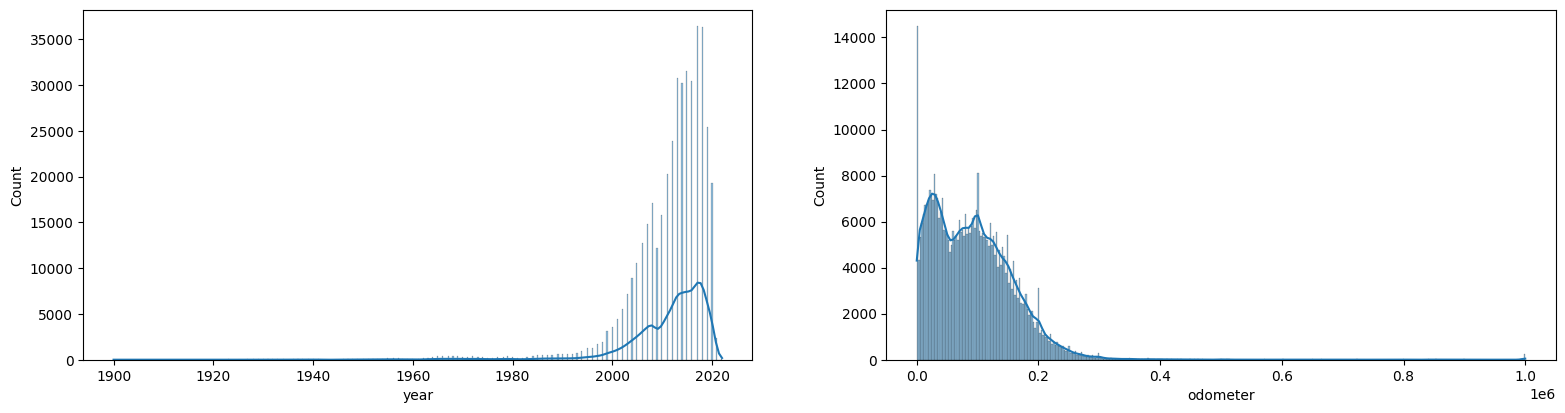

In [129]:
plt.figure (figsize= (19, 10))

for col in na_num_cols:
    plt.subplot (2, 2, na_num_cols.index (col) + 1)
    sns.histplot (data= df, x= col, kde= True)

plt.show ()

In [130]:

task = {
    'columns': ['odometer'],
    'action': 'df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan'
}

append_to_to_do (task)

# Median for all of na_num_cols

FILL_METHOD = 'median'


task = {
    "columns": na_num_cols,
    "action": f"fill missing values with {FILL_METHOD}",
}

append_to_to_do (task)

In [131]:
for col in na_num_cols:
    median = df [col].median ()
    df [col] = df [col].fillna (value= median)

In [132]:
df [na_num_cols].isna ().sum ().sum ()

np.int64(0)

In [203]:
price_zero = df[df["price"] == 0]

price_zero[[
    "price",
    "year",
    "manufacturer",
    "model",
    "condition",
    "odometer",
    "state"
]].head(50)

,price,year,manufacturer,model,condition,odometer,state
46,0,"2,011.00",jeep,compass,excellent,"99,615.00",al
126,0,"2,018.00",chevrolet,express cargo van,like new,"68,472.00",al
127,0,"2,019.00",chevrolet,express cargo van,like new,"69,125.00",al
128,0,"2,018.00",chevrolet,express cargo van,like new,"66,555.00",al
191,0,"2,015.00",nissan,sentra,excellent,"99,505.00",al
239,0,"2,019.00",chevrolet,silverado 1500,excellent,"25,127.00",al
242,0,"2,014.00",ford,Freightliner Cascadia,Unknown,100.00,al
244,0,"2,017.00",chevrolet,silverado 2500hd 4x4,like new,"102,000.00",al
258,0,"2,015.00",mercedes-benz,s-class,Unknown,"78,807.00",al
305,0,"2,018.00",mercedes-benz,e-class,Unknown,"34,099.00",al


In [207]:
df.loc[df["price"] == 0, "price"] = np.nan

In [212]:
task = {
    'columns': ['price'],
    'action': 'df.loc[df["price"] == 0, "price"] = np.nan'
}

append_to_to_do (task)

In [209]:
df ['price'].isna ().sum ()

np.int64(32888)

### We will not use these nan in train

### DONE ✅

### Categorical Columns

In [133]:
for col in na_cat_cols:
    print ('Col name:', col)
    print ('No.of unique values:', len (df [col].unique ()) - 1)
    print ('First 4 unique values:', df [col].unique ().tolist () [: 4])
    print ("Mode:", df [col].mode () [0])
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print (f'No.of missing:', df [col].isna ().sum ())
    print ('-' * 50)
    print ()

Col name: manufacturer
No.of unique values: 42
First 4 unique values: [nan, 'gmc', 'chevrolet', 'toyota']
Mode: ford
Missing %: 4.13%
No.of missing: 17635
--------------------------------------------------

Col name: model
No.of unique values: 29667
First 4 unique values: [nan, 'sierra 1500 crew cab slt', 'silverado 1500', 'silverado 1500 crew']
Mode: f-150
Missing %: 1.23%
No.of missing: 5266
--------------------------------------------------

Col name: condition
No.of unique values: 6
First 4 unique values: [nan, 'good', 'excellent', 'fair']
Mode: good
Missing %: 40.78%
No.of missing: 174080
--------------------------------------------------

Col name: cylinders
No.of unique values: 8
First 4 unique values: [nan, '8 cylinders', '6 cylinders', '4 cylinders']
Mode: 6 cylinders
Missing %: 41.62%
No.of missing: 177654
--------------------------------------------------

Col name: fuel
No.of unique values: 5
First 4 unique values: [nan, 'gas', 'other', 'diesel']
Mode: gas
Missing %: 0.70%


In [134]:
task = {
    "columns": ['manufacturer', 'fuel', 'title_status', 'transmission'],
    "action": "fill missing values with mode"
}

append_to_to_do (task)

In [135]:
for col in ['manufacturer', 'fuel', 'title_status', 'transmission']:
    mode = df [col].mode () [0]
    df [col] = df [col].fillna (value= mode)

In [136]:
df [['manufacturer', 'fuel', 'title_status', 'transmission']].isna ().sum ().sum ()

np.int64(0)

In [137]:
for col in ['manufacturer', 'fuel', 'title_status', 'transmission']:
    print (col)
    print (df [col].unique ().tolist ())
    print ('-' * 50)
    print ()

manufacturer
['ford', 'gmc', 'chevrolet', 'toyota', 'jeep', 'nissan', 'ram', 'mazda', 'cadillac', 'honda', 'dodge', 'lexus', 'jaguar', 'buick', 'chrysler', 'volvo', 'audi', 'infiniti', 'lincoln', 'alfa-romeo', 'subaru', 'acura', 'hyundai', 'mercedes-benz', 'bmw', 'mitsubishi', 'volkswagen', 'porsche', 'kia', 'rover', 'ferrari', 'mini', 'pontiac', 'fiat', 'tesla', 'saturn', 'mercury', 'harley-davidson', 'datsun', 'aston-martin', 'land rover', 'morgan']
--------------------------------------------------

fuel
['gas', 'other', 'diesel', 'hybrid', 'electric']
--------------------------------------------------

title_status
['clean', 'rebuilt', 'lien', 'salvage', 'missing', 'parts only']
--------------------------------------------------

transmission
['automatic', 'other', 'manual']
--------------------------------------------------



In [138]:
for col in ['manufacturer', 'fuel', 'title_status', 'transmission']:
    if col in na_cat_cols:
        na_cat_cols.remove (col)
print (na_cat_cols)


['model', 'condition', 'cylinders', 'drive', 'type', 'paint_color', 'posting_date']


In [139]:
for col in na_cat_cols:
    print ('Col name:', col)
    print ('No.of unique values:', len (df [col].unique ()) - 1)
    print ('First 4 unique values:', df [col].unique ().tolist () [: 4])
    print ("Mode:", df [col].mode () [0])
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print (f'No.of missing:', df [col].isna ().sum ())
    print ('-' * 50)
    print ()

Col name: model
No.of unique values: 29667
First 4 unique values: [nan, 'sierra 1500 crew cab slt', 'silverado 1500', 'silverado 1500 crew']
Mode: f-150
Missing %: 1.23%
No.of missing: 5266
--------------------------------------------------

Col name: condition
No.of unique values: 6
First 4 unique values: [nan, 'good', 'excellent', 'fair']
Mode: good
Missing %: 40.78%
No.of missing: 174080
--------------------------------------------------

Col name: cylinders
No.of unique values: 8
First 4 unique values: [nan, '8 cylinders', '6 cylinders', '4 cylinders']
Mode: 6 cylinders
Missing %: 41.62%
No.of missing: 177654
--------------------------------------------------

Col name: drive
No.of unique values: 3
First 4 unique values: [nan, 'rwd', '4wd', 'fwd']
Mode: 4wd
Missing %: 30.59%
No.of missing: 130550
--------------------------------------------------

Col name: type
No.of unique values: 13
First 4 unique values: [nan, 'pickup', 'truck', 'other']
Mode: sedan
Missing %: 21.75%
No.of miss

In [140]:
df ["model"].nunique ()

29667

In [141]:
df ["model"] = df ["model"].astype (str)

In [142]:
print ([x for x in df ['model'].unique ().tolist () if len (x) < 5])

['nan', 'f450', 'tlx', 'z4', 'rav4', 'f150', 'benz', 'echo', '525i', 'f750', '300m', 'f100', 'soul', 'srx', 'x3', 'sts', 'tl', '2500', 'edge', '1500', 'qx30', 'cls', 's60', 'jx35', '3500', '300', 'mdx', 'q7', 'trax', 'hhr', 'q50', 'x6', 'ex35', 'baja', '1988', 'tsx', 'mkz', '328i', 'x5', 'cr v', 'qx4', 'rx', '200', 'xj', 'f250', 'fx35', 'f550', 'rio', 'r XF', 'cx-5', 'rl', 'glk', 'q60', 'm35', 'is', 'cj7', 'e350', '3i', '4500', '5500', 'qx70', 'gx', 'mkc', 'cts', '300c', 'kona', 'CX-5', 'cr-v', '560', 'sl', 'juke', 'dart', '500', 'HINO', '535i', 'acty', 's80', 'ssr', 'rdx', 'a3', 'qx80', 'xts', 'e250', 'mkx', 'rc', 'a5', 'aura', 'es', 'all', '2', 'ls', 'dts', 'c10', 'f800', 'qx60', 's10', 'c20', 'Nash', '210', 'w150', 'rsx', 'flex', 'f350', 'q5', 'a4', '370z', 'm37', 'xlr', 'crx', 'cc', 'l300', 'hse', 'xc90', '530i', 'lr4', 'vibe', 'c250', 'ilx', '650i', 'qx56', 'hrv', '2001', 'g6', 'a6', 's500', 'e450', 'xk8', '5', 'hr-v', 'xt5', 'x1', 'ion', 'crv', 'ats', 'cx-3', 'i30', 'c230', '3', 

In [143]:
missing_values = [
    'nan',
    'NaN',
    'NAN',
    'Nan',
    'unknown',
    'Unknown',
    'ALL',
    'All',
    'ANY',
    'Any',
    'Any kind',
    'Any model',
    'Any maker',
    'All makes',
    'All cars',
    'All kinds',
    'All Makes',
    'Any car',
    'ANY CAR',
    'many',
    'various',
    'Variety',
    'anything',
    'etc',
    'etc.',
    'ect.',
    'etc, etc',
    'N/A',
    'n/a',
    'N.A',
    'N',
    'O',
    '',
    '.',
    '-',
    '?',
    '%',
    '1',
    '2',
    '3',
    '5',
    '6',
    '7',
    '8',
    '11',
    '15',
    '20',
    '24',
    'Junk',
    'junk',
    'Junk Cars',
    'Junk car',
    'unknown',
    'just',
    'Like New',
    'New',
    'many',
    'NONE',
    'Custom',
    'custom',
    ':',
    ';;',
    'Trade ins',
    'any and all'
]

df['model'] = df['model'].replace (missing_values, np.nan)


In [144]:
task = {
    "columns": ['model'],
    "action": "Replace all garbage values (name of the list is missing_values) with actual nan"
}

append_to_to_do (task)


In [145]:
print (f"Missing %: {df ['model'].isna ().sum () / len (df) * 100:.2f}%")
print (f'No.of missing:', df ['model'].isna ().sum ())



Missing %: 1.50%
No.of missing: 6391


In [146]:
df ["model"].value_counts (dropna= True).head (10)

,count
model,
f-150,8008
silverado 1500,5140
1500,4211
camry,3134
silverado,3022
accord,2969
wrangler,2848
civic,2799
altima,2779


In [147]:
df ['model'] = df ['model'].fillna (value= "Unknown")

In [148]:
df ['model'].isna ().sum ()

np.int64(0)

In [149]:
if 'model' in na_cat_cols:
    na_cat_cols.remove ('model')
print (na_cat_cols)

['condition', 'cylinders', 'drive', 'type', 'paint_color', 'posting_date']


In [150]:
for col in na_cat_cols:
    print ('Col name:', col)
    print ('No.of unique values:', len (df [col].unique ()) - 1)
    print ('First 4 unique values:', df [col].unique ().tolist () [: 4])
    print ("Mode:", df [col].mode () [0])
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print (f'No.of missing:', df [col].isna ().sum ())
    print ('-' * 50)
    print ()

Col name: condition
No.of unique values: 6
First 4 unique values: [nan, 'good', 'excellent', 'fair']
Mode: good
Missing %: 40.78%
No.of missing: 174080
--------------------------------------------------

Col name: cylinders
No.of unique values: 8
First 4 unique values: [nan, '8 cylinders', '6 cylinders', '4 cylinders']
Mode: 6 cylinders
Missing %: 41.62%
No.of missing: 177654
--------------------------------------------------

Col name: drive
No.of unique values: 3
First 4 unique values: [nan, 'rwd', '4wd', 'fwd']
Mode: 4wd
Missing %: 30.59%
No.of missing: 130550
--------------------------------------------------

Col name: type
No.of unique values: 13
First 4 unique values: [nan, 'pickup', 'truck', 'other']
Mode: sedan
Missing %: 21.75%
No.of missing: 92847
--------------------------------------------------

Col name: paint_color
No.of unique values: 12
First 4 unique values: [nan, 'white', 'blue', 'red']
Mode: white
Missing %: 30.50%
No.of missing: 130181
----------------------------

In [151]:
df.dropna (subset= ['posting_date'], inplace= True) # 57 Only

if 'posting_date' in na_cat_cols:
    na_cat_cols.remove ('posting_date')

for col in na_cat_cols:
    df [col] = df [col].fillna ("Unknown")

In [152]:
task = {
    'columns': ['posting_date'],
    'action': 'dropna'
}

append_to_to_do (task)


task = {
    'columns': ['model', 'condition', 'cylinders', 'drive', 'type', 'paint_color'],
    'action': 'fillna with Unknown'
}

append_to_to_do (task)


In [153]:
df.isna ().sum ().sum ()

np.int64(0)

In [154]:
df.head ()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
27,auburn,33590,"2,014.00",gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,"57,923.00",clean,other,Unknown,pickup,white,al,2021-05-04T12:31:18-0500
28,auburn,22590,"2,010.00",chevrolet,silverado 1500,good,8 cylinders,gas,"71,229.00",clean,other,Unknown,pickup,blue,al,2021-05-04T12:31:08-0500
29,auburn,39590,"2,020.00",chevrolet,silverado 1500 crew,good,8 cylinders,gas,"19,160.00",clean,other,Unknown,pickup,red,al,2021-05-04T12:31:25-0500
30,auburn,30990,"2,017.00",toyota,tundra double cab sr,good,8 cylinders,gas,"41,124.00",clean,other,Unknown,pickup,red,al,2021-05-04T10:41:31-0500
31,auburn,15000,"2,013.00",ford,f-150 xlt,excellent,6 cylinders,gas,"128,000.00",clean,automatic,rwd,truck,black,al,2021-05-03T14:02:03-0500


In [155]:
print ("No.of Lost rows:", num_of_rows - df.shape [0])
print ("Lost %:", (num_of_rows - df.shape [0]) / num_of_rows * 100)

No.of Lost rows: 96
Lost %: 0.022488755622188904


## Analyze Target

In [156]:
df ["price"].describe ()

,price
count,"426,784.00"
mean,"75,212.79"
std,"12,183,652.19"
min,0.00
25%,"5,900.00"
50%,"13,950.00"
75%,"26,488.25"
max,"3,736,928,711.00"


# 3.7 billions for a car 🫨🫨🫨🫨🫨

In [157]:
(df["price"] == 0).sum ()

np.int64(32888)

In [158]:
(df["price"] == 0).mean () * 100

np.float64(7.706005848391692)

In [159]:
df [df ["price"] == 0][
    ["price", "year", "manufacturer", "model", "condition", "title_status"]
].sample (20)

,price,year,manufacturer,model,condition,title_status
262139,0,"2,019.00",toyota,corolla,Unknown,clean
346511,0,"2,017.00",nissan,pathfinder,Unknown,clean
310798,0,"2,019.00",gmc,sierra 3500 slt duramax die,Unknown,clean
334761,0,"2,013.00",ford,INTERNATIONAL LF687,Unknown,clean
409545,0,"2,010.00",acura,mdx 3.7l,Unknown,clean
279577,0,"2,013.00",cadillac,xts,Unknown,clean
181374,0,"2,018.00",mercedes-benz,e-class,Unknown,clean
315768,0,"2,014.00",ram,2500 laramie,Unknown,clean
309048,0,"2,016.00",toyota,rav4 le suv,excellent,clean
319025,0,"2,019.00",mazda,cx-5 signature,Unknown,clean


### Seems normal cars 🤷‍♂️ maybe it is for free

In [160]:
(df ["price"] > 500_000).sum ()

np.int64(68)

In [161]:
(df ["price"] > 500_000).mean () * 100

np.float64(0.01593311839244208)

In [162]:
df [df ["price"] > 500_000]["price"].value_counts ()

,count
price,
1234567,13
1000000,7
123456789,6
12345678,6
1111111,5
987654321,2
3024942282,2
3736928711,2
777777,2


In [163]:
print (df[df["price"] > 500_000]["price"].unique ().tolist ())

[987654321, 99999999, 1111111, 1111111111, 3009548743, 2000000, 655000, 1000000, 3024942282, 990000, 6995495, 516999, 17000000, 123456789, 566567, 1234567890, 1234567, 1410065407, 554900, 135008900, 113456789, 5000000, 1666666, 12345678, 10004000, 777777, 3736928711, 3226714, 11111111, 25003000, 999999]


In [164]:
suspicious_prices = [
    987654321,
    99999999,
    1111111,
    1111111111,
    123456789,
    1234567890,
    1234567,
    1666666,
    12345678,
    777777,
    11111111,
    113456789,
    999999
]

df = df [~df ["price"].isin (suspicious_prices)]

In [165]:
(df ["price"] > 500_000).sum ()

np.int64(26)

In [166]:
df [df ["price"] > 500_000] ['price'].value_counts ()

,count
price,
1000000,7
3024942282,2
3736928711,2
3009548743,1
2000000,1
655000,1
6995495,1
516999,1
17000000,1


### I see these numbers is weird

In [167]:
task = {
    'columns': ['price'],
    'action': 'drop all values that greater than 500_000'
}


append_to_to_do (task)

In [168]:
df = df [df["price"] <= 500_000]

In [169]:
(df["price"] > 500_000).sum ()

np.int64(0)

In [170]:
df ['price'].describe ()

,price
count,"426,716.00"
mean,"17,445.86"
std,"15,628.47"
min,0.00
25%,"5,900.00"
50%,"13,950.00"
75%,"26,430.00"
max,"470,000.00"


## Detect & Handle Outliers

In [171]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
Index: 426716 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426716 non-null  object 
 1   price         426716 non-null  int64  
 2   year          426716 non-null  float64
 3   manufacturer  426716 non-null  object 
 4   model         426716 non-null  object 
 5   condition     426716 non-null  object 
 6   cylinders     426716 non-null  object 
 7   fuel          426716 non-null  object 
 8   odometer      426716 non-null  float64
 9   title_status  426716 non-null  object 
 10  transmission  426716 non-null  object 
 11  drive         426716 non-null  object 
 12  type          426716 non-null  object 
 13  paint_color   426716 non-null  object 
 14  state         426716 non-null  object 
 15  posting_date  426716 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 55.3+ MB


In [172]:
num_cols = df.select_dtypes (include= "number").columns.tolist ()
num_cols

['price', 'year', 'odometer']

In [173]:
def check_outliers(
    data, column,
    specific_lower : bool = False, lower_bound : float = 0.0,
    specific_upper : bool = False, upper_bound : float = 0.0
    ):
    q1 = data [column].quantile (0.25)
    q3 = data [column].quantile (0.75)

    iqr = q3 - q1

    if specific_lower:
        lower = lower_bound
    else:
        lower = q1 - 1.5 * iqr


    if specific_upper:
        upper = upper_bound
    else:
        upper = q3 + 1.5 * iqr

    outliers = data[
        (data [column] < lower) |
        (data [column] > upper)
    ]

    print(f"Column: {column}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower Bound: {lower:.2f}")
    print(f"Upper Bound: {upper:.2f}")
    print(f"Outliers: {len(outliers):,}")
    print(f"Percentage: {len(outliers) / len(data) * 100:.2f}%")

In [174]:
num_cols

['price', 'year', 'odometer']

### Price

Column: price
Q1: 5900.00
Q3: 26430.00
IQR: 20530.00
Lower Bound: 0.00
Upper Bound: 57225.00
Outliers: 8,124
Percentage: 1.90%


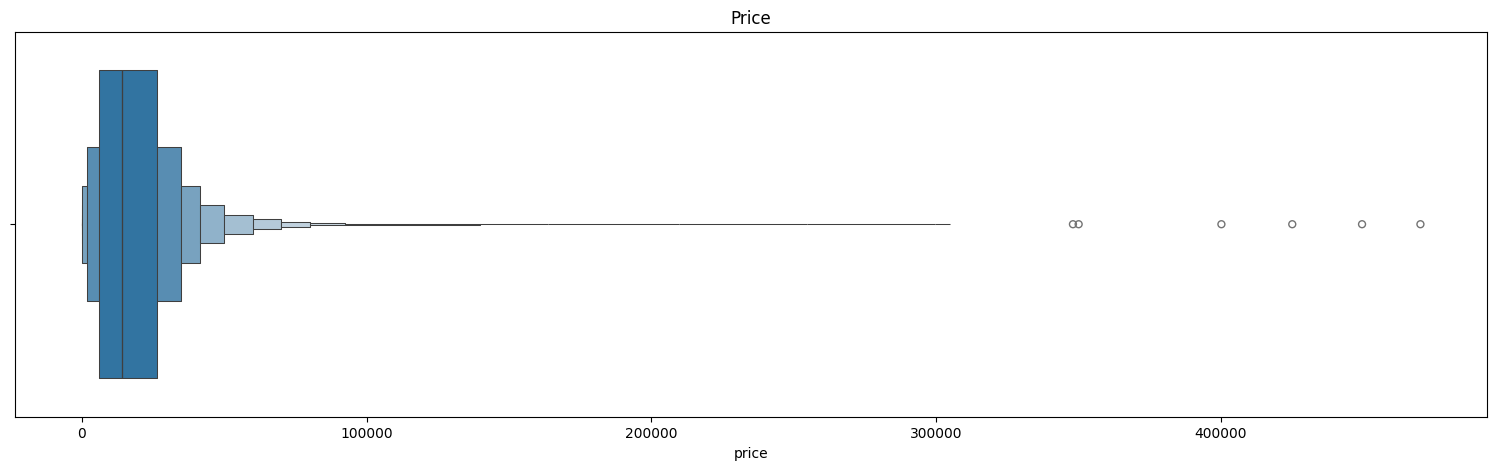

In [175]:
check_outliers (df, "price", specific_lower= True, lower_bound= 0.0)
plt.figure (figsize= (19, 5))
sns.boxenplot (data= df, x= 'price')
plt.title ('Price')
plt.show ()

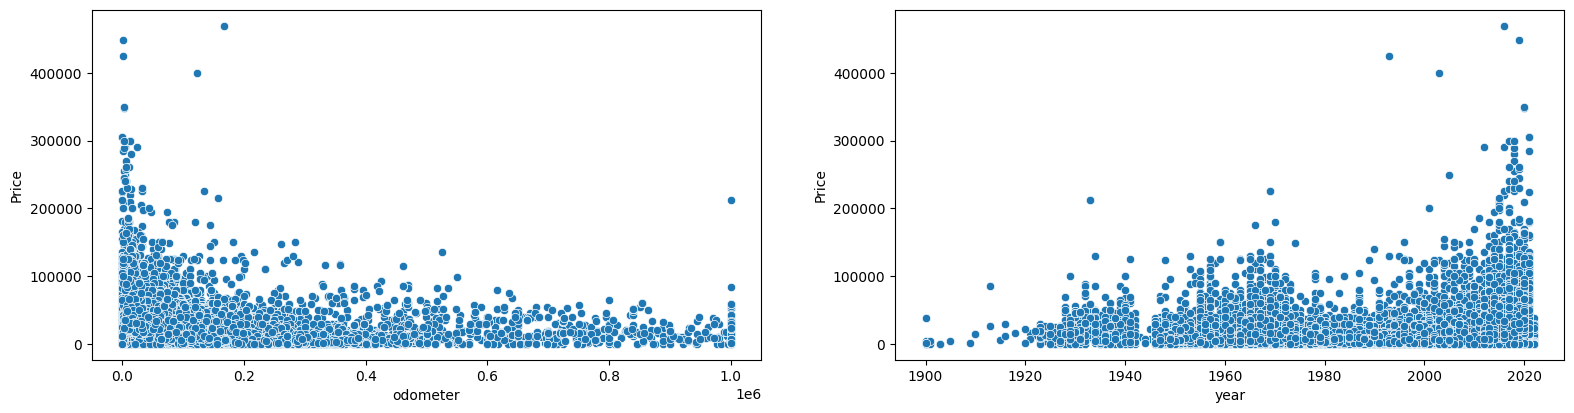

In [176]:
plt.figure (figsize= (19, 10))

cols= ['odometer', 'year']

for col in cols:
    plt.subplot (2, 2, cols.index (col) + 1)
    sns.scatterplot (data= df, x= col, y= 'price')
    plt.xlabel (col)
    plt.ylabel ('Price')


plt.show ()

In [177]:
print ("No.of cars over 300,000:", sum (df [df ['price'] > 300_000] ['price'].value_counts ()))
df [df ['price'] > 300_000] ['price'].value_counts ()

No.of cars over 300,000: 9


,count
price,
304995,3
347999,1
349999,1
470000,1
425000,1
400123,1
449500,1


In [178]:
df[df["price"] > 300_000][
    ["price", "year", "manufacturer", "model", "condition", "odometer"]
]

,price,year,manufacturer,model,condition,odometer
44387,347999,"2,020.00",ferrari,f8 tributo,excellent,"3,000.00"
45428,349999,"2,020.00",ferrari,f8 tributo,excellent,"2,800.00"
88588,304995,"2,021.00",porsche,911,Unknown,22.00
90274,304995,"2,021.00",porsche,911,Unknown,22.00
113357,470000,"2,016.00",ford,hINO 268,good,"167,268.00"
133497,425000,"1,993.00",jeep,wrangler,Unknown,380.00
328193,400123,"2,003.00",ford,Unknown,fair,"123,321.00"
360604,449500,"2,019.00",ferrari,488 gtb,Unknown,500.00
399462,304995,"2,021.00",porsche,911,Unknown,22.00


In [179]:
df.loc[[113357, 133497]].T

,113357,133497
region,south florida,east idaho
price,470000,425000
year,"2,016.00","1,993.00"
manufacturer,ford,jeep
model,hINO 268,wrangler
condition,good,Unknown
cylinders,Unknown,Unknown
fuel,diesel,gas
odometer,"167,268.00",380.00
title_status,clean,clean


In [180]:
suspicious_rows = [113357, 133497]

df = df.drop (index= suspicious_rows)

In [181]:
task = {
    'columns': ['price'],
    'action': 'drop suspicious rows: [113357, 133497]'
}

append_to_to_do (task)

### Year

In [182]:
df ['year'].describe ()

,year
count,"426,714.00"
mean,"2,011.24"
std,9.43
min,"1,900.00"
25%,"2,008.00"
50%,"2,013.00"
75%,"2,017.00"
max,"2,022.00"


Column: year
Q1: 2008.00
Q3: 2017.00
IQR: 9.00
Lower Bound: 1994.50
Upper Bound: 2030.50
Outliers: 15,872
Percentage: 3.72%


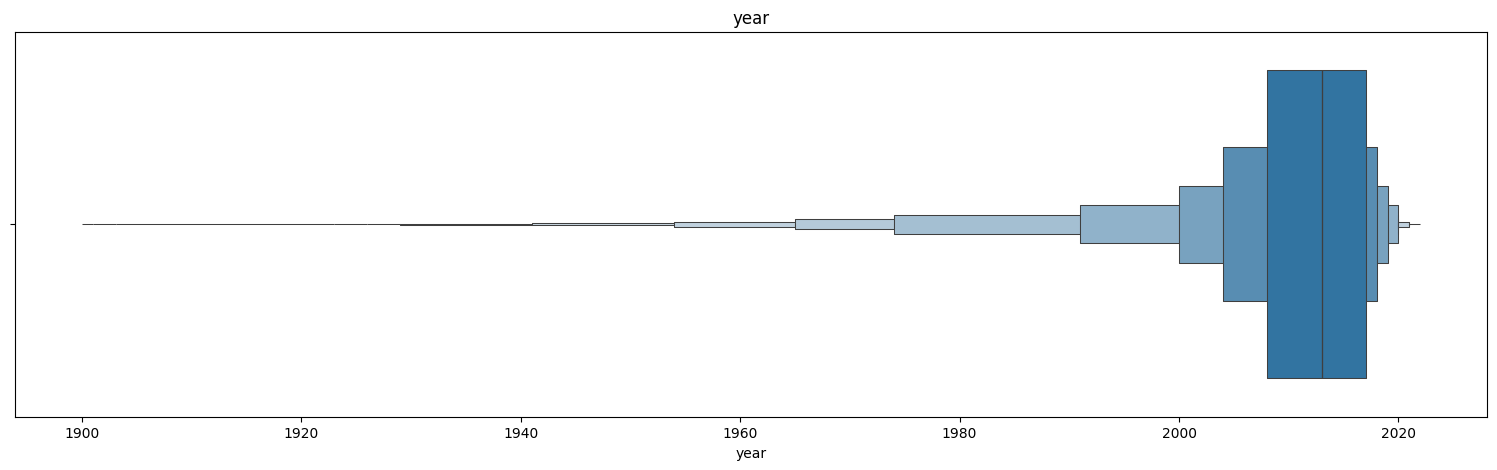

In [183]:
check_outliers (df, "year")
plt.figure (figsize= (19, 5))
sns.boxenplot (data= df, x= 'year')
plt.title ('year')
plt.show ()

In [184]:
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())

print("\nYears below 1900:")
print((df["year"] < 1900).sum())

print("\nYears above 2022:")
print((df["year"] > 2022).sum())

Minimum year: 1900.0
Maximum year: 2022.0

Years below 1900:
0

Years above 2022:
0


In [185]:
Q1 = df["year"].quantile(0.25)
Q3 = df["year"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

year_outliers = df[
    (df["year"] < lower_bound) |
    (df["year"] > upper_bound)
]

year_outliers

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
37,auburn,4500,"1,992.00",jeep,cherokee,excellent,6 cylinders,gas,"192,000.00",clean,automatic,4wd,Unknown,Unknown,al,2021-05-03T07:38:05-0500
101,auburn,12990,"1,968.00",volvo,Unknown,Unknown,Unknown,gas,"99,999.00",clean,manual,Unknown,Unknown,Unknown,al,2021-04-19T07:46:40-0500
137,auburn,2500,"1,966.00",ford,1966 C-30 1 ton,good,6 cylinders,gas,"47,000.00",clean,manual,rwd,pickup,brown,al,2021-04-11T07:07:52-0500
208,birmingham,2500,"1,976.00",chevrolet,malibu classic,Unknown,Unknown,gas,100.00,clean,automatic,Unknown,Unknown,Unknown,al,2021-05-04T07:11:30-0500
210,birmingham,1300,"1,969.00",mercedes-benz,benz,Unknown,Unknown,gas,"12,774.00",clean,automatic,Unknown,Unknown,Unknown,al,2021-05-04T07:10:04-0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426729,wyoming,20000,"1,951.00",jeep,cj 3a willys,like new,4 cylinders,gas,"14,409.00",clean,manual,4wd,other,red,wy,2021-04-10T16:31:26-0600
426762,wyoming,7000,"1,982.00",mazda,rx& gls sport,excellent,other,gas,"80,000.00",clean,automatic,rwd,coupe,brown,wy,2021-04-07T19:21:02-0600
426809,wyoming,18000,"1,990.00",jeep,gand wagoneer,good,8 cylinders,gas,"114,400.00",clean,automatic,4wd,SUV,black,wy,2021-04-06T21:02:26-0600
426831,wyoming,9800,"1,985.00",nissan,300zx coupe with t-tops,like new,6 cylinders,gas,"115,000.00",clean,automatic,rwd,hatchback,red,wy,2021-04-05T18:10:52-0600


In [219]:
print (df ['model'].unique ().tolist ())

['sierra 1500 crew cab slt', 'silverado 1500', 'silverado 1500 crew', 'tundra double cab sr', 'f-150 xlt', 'sierra 2500 hd extended cab', 'silverado 1500 double', 'tacoma', 'colorado extended cab', 'corvette grand sport', 'cherokee', 'wrangler unlimited sport', 'silverado 1500 regular', 'colorado crew cab z71', 'tacoma access cab pickup', 'camaro ss coupe 2d', 'tundra crewmax sr5 pickup', 'ranger supercrew xl pickup', 'frontier crew cab pro-4x', 'compass', 'f150 super cab xl pickup 4d', 'tacoma double cab sr5', 'wrangler sport suv 2d', 'f150 supercrew cab xlt', '1500 regular cab tradesman', 'mx-5 miata club', 'ranger supercab xl pickup', 'xt4 sport suv 4d', 'f250 super duty', 'renegade sport suv 4d', 'f150 regular cab xl pickup', 'sierra 1500 regular cab', 'odyssey', '1500 quad cab express pickup', 'sierra 1500 extended cab slt', '1500 classic regular cab', 'mustang gt premium', 'f450', 'silverado 1500 ld', 'tundra double cab pickup', 'wrangler unlimited sahara', 'charger rt 4dr sedan'

In [217]:
year_1900 = df[df["year"] == 1900]

print("Count:", len(year_1900))

year_1900[[
    "price",
    "manufacturer",
    "model",
    "condition",
    "odometer",
    "state"
]]

Count: 12


,price,manufacturer,model,condition,odometer,state
29955,1.00,ford,Unknown,fair,"100,000.00",ca
32544,1.00,ford,Unknown,fair,"100,000.00",ca
42454,"38,250.00",acura,rdx,new,"4,500.00",ca
44754,1.00,ford,Unknown,good,"1,000.00",ca
94319,1.00,ford,power wagon,Unknown,"2,300.00",fl
95914,1.00,ford,power wagon,Unknown,"2,300.00",fl
96564,1.00,ford,power wagon,Unknown,"2,300.00",fl
123023,"4,500.00",ford,cushman white van,excellent,"2,136.00",ga
126977,1.00,ford,The earth is flat,good,"123,000.00",ga
154138,75.00,ford,Unknown,Unknown,"10,000.00",in


In [186]:
['odometer']

['odometer']

Column: odometer
Q1: 38123.00
Q3: 132500.00
IQR: 94377.00
Lower Bound: -103442.50
Upper Bound: 274065.50
Outliers: 3,949
Percentage: 0.93%


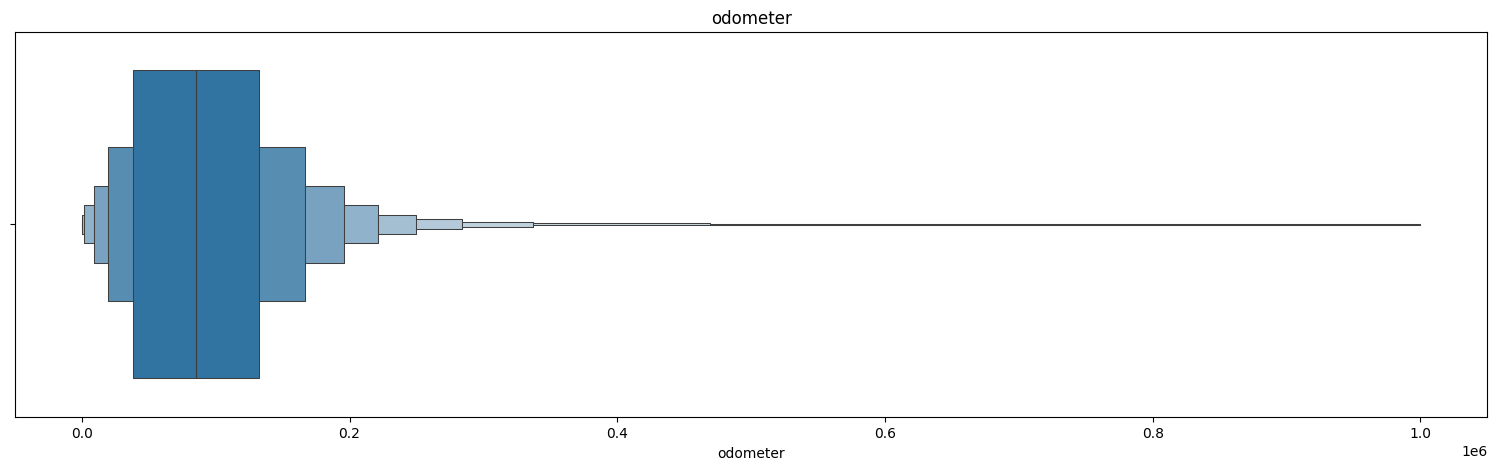

In [187]:
check_outliers (df, "odometer")
plt.figure (figsize= (19, 5))
sns.boxenplot (data= df, x= 'odometer')
plt.title ('odometer')
plt.show ()

In [188]:
df["odometer"].describe ()

,odometer
count,"426,714.00"
mean,"92,440.87"
std,"70,214.33"
min,0.00
25%,"38,123.00"
50%,"85,341.00"
75%,"132,500.00"
max,"999,999.00"


In [189]:
print (df.duplicated ().sum ())
print (df.isna ().sum ().sum())

0
0


In [190]:
for x in to_do:
    pprint (x)
    print ('-' * 20)
    print ()
    print ()

{'action': 'drop useless columns',
 'columns': ['id',
             'url',
             'region_url',
             'VIN',
             'image_url',
             'description',
             'county',
             'lat',
             'long']}
--------------------


{'action': 'drop duplicates',
 'columns': ['region',
             'price',
             'year',
             'manufacturer',
             'model',
             'condition',
             'cylinders',
             'fuel',
             'odometer',
             'title_status',
             'transmission',
             'drive',
             'size',
             'type',
             'paint_color',
             'state',
             'posting_date']}
--------------------


{'action': 'df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan',
 'columns': ['odometer']}
--------------------


{'action': 'fill missing values with median', 'columns': ['year', 'odometer']}
--------------------


{'action': 'fill missing values with mode',
 

In [191]:
print (df.shape)
num_of_rows - df.shape [0]

(426714, 16)


166

year == 1900	🔍 Inspect first <br>
price == 0	🔍 أهم حاجة نفحصها قبل القرار<br>
odometer == 999999	✅ Keep<br>